# What this notebook does

**Recap**  

This notebook continues from `01_feature_engineering_experiments.ipynb`.

By this point we already have:
- the merged modeling dataset
- the feature-engineering metadata
- a rough idea of which feature family works best

This notebook focuses on **tree-based models**, because they have been stronger than the LSTM so far.

The goal here is to:
- load the engineered dataset
- load the selected features from Notebook 1
- train several tree-based models
- tune them using a chronological train/validation/test split
- compare results with clear visualizations
- save the best model metrics for the final comparison notebook

# 02 Tree Model Tuning

## Objective
This notebook tunes and compares several tree-based models for Brent direction prediction.

The models tested are:
- Random Forest
- Gradient Boosting
- XGBoost (if installed)
- LightGBM (if installed)

The notebook uses:
- the engineered dataset from Notebook 1
- the selected feature list from Notebook 1
- a chronological split to avoid leakage

## 1. Imports and configuration

In [3]:
import os
import json
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except Exception:
    XGB_AVAILABLE = False

try:
    from lightgbm import LGBMClassifier
    LGBM_AVAILABLE = True
except Exception:
    LGBM_AVAILABLE = False

In [4]:
# =========================
# Paths
# =========================

try:
    BASE = Path.cwd().parent   # if notebook is inside prediction/
except:
    BASE = Path.cwd()

OUT_DIR = BASE / "finetuning" / "data"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = OUT_DIR / "merged_modeling_brent.csv"
META_PATH = OUT_DIR / "feature_engineering_metadata_brent.json"
RESULTS_JSON_PATH = OUT_DIR / "tree_model_tuning_results_brent.json"
RESULTS_PNG_PATH = OUT_DIR / "tree_model_tuning_results_brent.png"

TARGET_COL = "target_up"
DATE_COL = "date"
RANDOM_STATE = 42

## 2. Load the engineered dataset and selected features

In [5]:
df = pd.read_csv(DATA_PATH)
df[DATE_COL] = pd.to_datetime(df[DATE_COL])

with open(META_PATH, "r") as f:
    metadata = json.load(f)

selected_features = metadata["selected_top_features"]
best_feature_set = metadata["best_feature_set"]

print("Dataset shape:", df.shape)
print("Best feature set from Notebook 1:", best_feature_set)
print("Selected features:", selected_features)
df.head()

Dataset shape: (457, 41)
Best feature set from Notebook 1: base_plus_sentiment_lags
Selected features: ['log_return', 'sentiment_std_lag1', 'avg_sentiment_lag2', 'roll5_ret', 'sentiment_std_roll3_mean', 'sentiment_std', 'sentiment_std_roll5_mean', 'roll20_vol', 'roll10_ret', 'avg_sentiment_roll5_std', 'avg_sentiment_lag3', 'sentiment_std_lag2', 'avg_sentiment_roll5_mean', 'avg_sentiment_roll3_std', 'sentiment_std_lag3']


,date,price,avg_sentiment,sentiment_std,news_volume,log_return,roll5_ret,roll10_ret,roll20_vol,ma5,...,roll10_ret_lag2,roll20_vol_lag1,roll20_vol_lag2,ma5_ratio_lag1,ma5_ratio_lag2,ma20_ratio_lag1,ma20_ratio_lag2,avg_sentiment_x_log_return,sentiment_std_x_roll5_ret,avg_sentiment_x_roll20_vol
0,2024-05-02,84.81,-0.128828,0.790458,10,0.014968,-0.038059,-0.040780,0.018552,86.996,...,-0.034094,0.018057,0.015663,0.953180,0.994163,0.931428,0.979751,-0.001928,-0.030084,-0.002390
1,2024-05-03,83.60,-0.308522,0.675821,8,-0.014370,-0.073210,-0.050839,0.017257,85.726,...,-0.069240,0.018552,0.018057,0.974872,0.953180,0.948387,0.931428,0.004433,-0.049477,-0.005324
2,2024-05-07,82.69,0.110975,0.553279,15,-0.010945,-0.067226,-0.054252,0.017243,84.576,...,-0.040780,0.017257,0.018552,0.975200,0.974872,0.939695,0.948387,-0.001215,-0.037195,0.001914
3,2024-05-08,82.44,-0.030889,0.598770,12,-0.003028,-0.067876,-0.068556,0.017107,83.418,...,-0.050839,0.017243,0.017257,0.977701,0.975200,0.934213,0.939695,0.000094,-0.040642,-0.000528
4,2024-05-09,83.27,-0.164963,0.632030,14,0.010018,-0.003357,-0.066773,0.017456,83.362,...,-0.054252,0.017107,0.017243,0.988276,0.977701,0.936515,0.934213,-0.001653,-0.002122,-0.002880


## 3. Finalize feature list

This notebook uses the selected features from Notebook 1 if they exist in the dataset.
If any are missing, they are removed safely.

In [6]:
feature_cols = [c for c in selected_features if c in df.columns]

print("No. selected features found:", len(feature_cols))
print(feature_cols)

No. selected features found: 15
['log_return', 'sentiment_std_lag1', 'avg_sentiment_lag2', 'roll5_ret', 'sentiment_std_roll3_mean', 'sentiment_std', 'sentiment_std_roll5_mean', 'roll20_vol', 'roll10_ret', 'avg_sentiment_roll5_std', 'avg_sentiment_lag3', 'sentiment_std_lag2', 'avg_sentiment_roll5_mean', 'avg_sentiment_roll3_std', 'sentiment_std_lag3']


## 4. Chronological split

In [7]:
# 70 / 15 / 15 split
n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df   = df.iloc[train_end:val_end].copy()
test_df  = df.iloc[val_end:].copy()

print("Train rows:", len(train_df))
print("Val rows  :", len(val_df))
print("Test rows :", len(test_df))

print("\\nTrain date range:", train_df[DATE_COL].min(), "->", train_df[DATE_COL].max())
print("Val date range  :", val_df[DATE_COL].min(), "->", val_df[DATE_COL].max())
print("Test date range :", test_df[DATE_COL].min(), "->", test_df[DATE_COL].max())


Train rows: 319
Val rows  : 69
Test rows : 69
\nTrain date range: 2024-05-02 00:00:00 -> 2025-08-06 00:00:00
Val date range  : 2025-08-07 00:00:00 -> 2025-11-12 00:00:00
Test date range : 2025-11-13 00:00:00 -> 2026-02-23 00:00:00


## 5. Helper functions

In [8]:
def evaluate_binary_model(model, train_df, val_df, test_df, feature_cols, target_col):
    X_train = train_df[feature_cols].copy()
    y_train = train_df[target_col].copy()
    
    X_val = val_df[feature_cols].copy()
    y_val = val_df[target_col].copy()
    
    X_test = test_df[feature_cols].copy()
    y_test = test_df[target_col].copy()
    
    model.fit(X_train, y_train)
    
    val_preds = model.predict(X_val)
    test_preds = model.predict(X_test)
    
    if hasattr(model, "predict_proba"):
        val_probs = model.predict_proba(X_val)[:, 1]
        test_probs = model.predict_proba(X_test)[:, 1]
    else:
        val_probs = None
        test_probs = None
    
    result = {
        "model_obj": model,
        "val_accuracy": accuracy_score(y_val, val_preds),
        "val_f1": f1_score(y_val, val_preds),
        "val_roc_auc": roc_auc_score(y_val, val_probs) if val_probs is not None else np.nan,
        "test_accuracy": accuracy_score(y_test, test_preds),
        "test_f1": f1_score(y_test, test_preds),
        "test_roc_auc": roc_auc_score(y_test, test_probs) if test_probs is not None else np.nan,
        "val_preds": val_preds,
        "test_preds": test_preds,
        "val_probs": val_probs,
        "test_probs": test_probs,
        "feature_cols": feature_cols
    }
    return result

In [9]:
def plot_confusion_matrix_full(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    cm_pct = cm / cm.sum() * 100
    
    labels = ["Down", "Up"]
    annot = np.empty_like(cm).astype(str)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f"{cm[i, j]}\n({cm_pct[i, j]:.1f}%)"

    plt.figure(figsize=(5.5, 4.5))
    sns.heatmap(
        cm,
        annot=annot,
        fmt="",
        cmap="Blues",
        cbar=False,
        xticklabels=labels,
        yticklabels=labels
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.tight_layout()
    plt.show()

## 6. Define model candidates

In [10]:
model_configs = []

# Random Forest
rf_candidates = [
    ("RandomForest_depth5", RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=RANDOM_STATE
    )),
    ("RandomForest_depth7", RandomForestClassifier(
        n_estimators=300,
        max_depth=7,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=RANDOM_STATE
    )),
    ("RandomForest_depthNone", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=RANDOM_STATE
    )),
]

model_configs.extend(rf_candidates)

In [11]:
# Gradient Boosting
gb_candidates = [
    ("GradientBoosting_lr005", GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    )),
    ("GradientBoosting_lr01", GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.10,
        max_depth=3,
        random_state=RANDOM_STATE
    )),
]

model_configs.extend(gb_candidates)

In [12]:
# XGBoost
if XGB_AVAILABLE:
    xgb_candidates = [
        ("XGBoost_depth3", XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=RANDOM_STATE
        )),
        ("XGBoost_depth4", XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=RANDOM_STATE
        )),
    ]
    model_configs.extend(xgb_candidates)

In [13]:
# LightGBM
if LGBM_AVAILABLE:
    lgbm_candidates = [
        ("LightGBM_leaf15", LGBMClassifier(
            n_estimators=200,
            learning_rate=0.05,
            num_leaves=15,
            max_depth=5,
            random_state=RANDOM_STATE
        )),
        ("LightGBM_leaf31", LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            max_depth=7,
            random_state=RANDOM_STATE
        )),
    ]
    model_configs.extend(lgbm_candidates)

In [14]:
print("Total model candidates:", len(model_configs))
for name, _ in model_configs:
    print("-", name)

Total model candidates: 9
- RandomForest_depth5
- RandomForest_depth7
- RandomForest_depthNone
- GradientBoosting_lr005
- GradientBoosting_lr01
- XGBoost_depth3
- XGBoost_depth4
- LightGBM_leaf15
- LightGBM_leaf31


## 7. Run model tuning

In [15]:
results = []

for model_name, model in model_configs:
    r = evaluate_binary_model(
        model=model,
        train_df=train_df,
        val_df=val_df,
        test_df=test_df,
        feature_cols=feature_cols,
        target_col=TARGET_COL
    )
    
    results.append({
        "model_name": model_name,
        "val_accuracy": r["val_accuracy"],
        "val_f1": r["val_f1"],
        "val_roc_auc": r["val_roc_auc"],
        "test_accuracy": r["test_accuracy"],
        "test_f1": r["test_f1"],
        "test_roc_auc": r["test_roc_auc"],
        "model_obj": r["model_obj"],
        "test_preds": r["test_preds"],
        "test_probs": r["test_probs"],
        "feature_cols": r["feature_cols"]
    })

results_df = pd.DataFrame(results).sort_values(
    ["val_roc_auc", "val_f1", "val_accuracy"],
    ascending=False
).reset_index(drop=True)

results_df[[
    "model_name",
    "val_accuracy",
    "val_f1",
    "val_roc_auc",
    "test_accuracy",
    "test_f1",
    "test_roc_auc"
]]

[LightGBM] [Info] Number of positive: 155, number of negative: 164
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000392 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1606
[LightGBM] [Info] Number of data points in the train set: 319, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.485893 -> initscore=-0.056441
[LightGBM] [Info] Start training from score -0.056441
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

,model_name,val_accuracy,val_f1,val_roc_auc,test_accuracy,test_f1,test_roc_auc
0,LightGBM_leaf15,0.608696,0.597015,0.666667,0.536232,0.589744,0.524618
1,LightGBM_leaf31,0.608696,0.584615,0.659091,0.550725,0.607595,0.522920
2,GradientBoosting_lr01,0.608696,0.584615,0.638047,0.536232,0.542857,0.506791
3,XGBoost_depth4,0.579710,0.567164,0.623737,0.579710,0.591549,0.540747
4,XGBoost_depth3,0.579710,0.539683,0.617003,0.521739,0.547945,0.519525
5,RandomForest_depth5,0.536232,0.483871,0.579966,0.536232,0.515152,0.564516
6,RandomForest_depth7,0.550725,0.507937,0.569024,0.565217,0.531250,0.584890
7,RandomForest_depthNone,0.550725,0.523077,0.561448,0.637681,0.637681,0.587436
8,GradientBoosting_lr005,0.565217,0.531250,0.560606,0.536232,0.529412,0.466893


## 8. Visualize validation and test performance

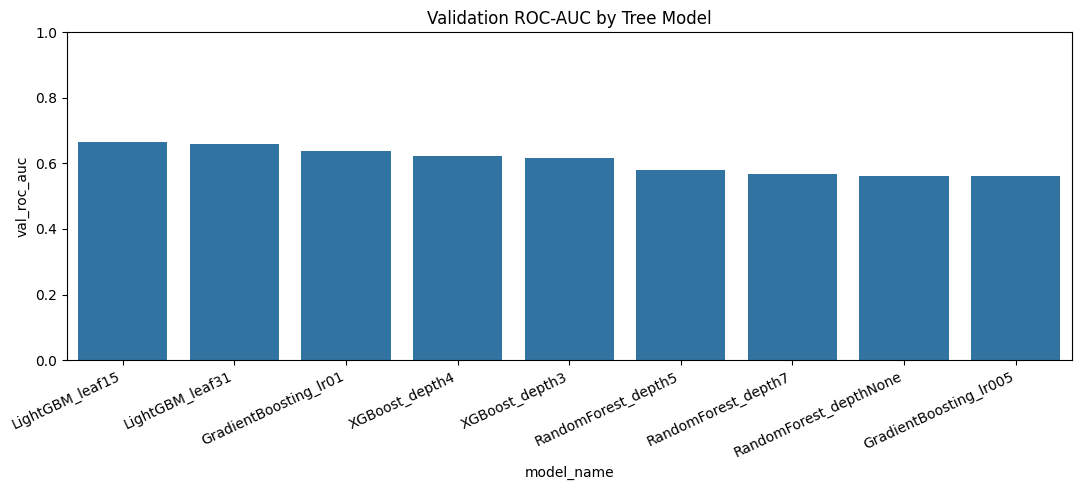

In [16]:
plt.figure(figsize=(11, 5))
sns.barplot(data=results_df, x="model_name", y="val_roc_auc")
plt.xticks(rotation=25, ha="right")
plt.title("Validation ROC-AUC by Tree Model")
plt.ylim(0.0, 1.0)
plt.tight_layout()
plt.show()

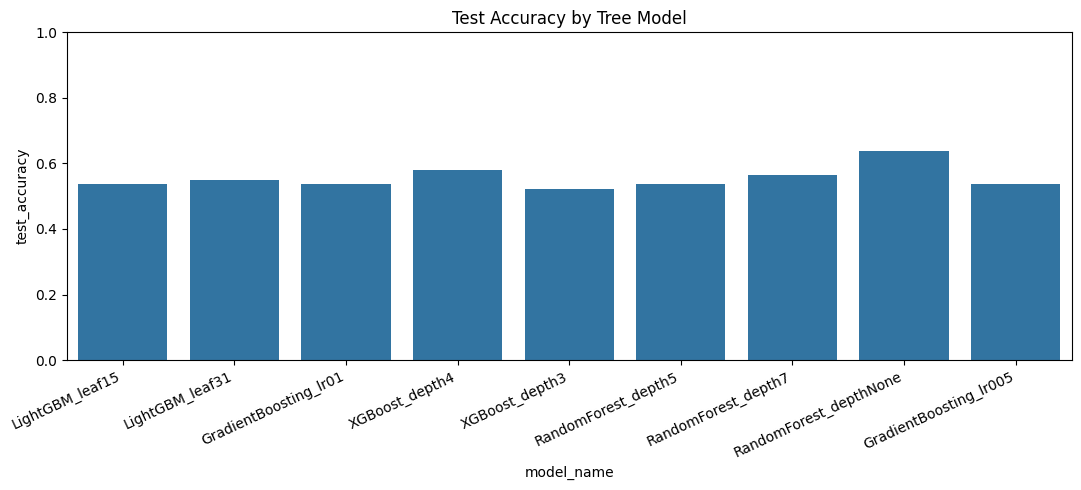

In [17]:
plt.figure(figsize=(11, 5))
sns.barplot(data=results_df, x="model_name", y="test_accuracy")
plt.xticks(rotation=25, ha="right")
plt.title("Test Accuracy by Tree Model")
plt.ylim(0.0, 1.0)
plt.tight_layout()
plt.show()

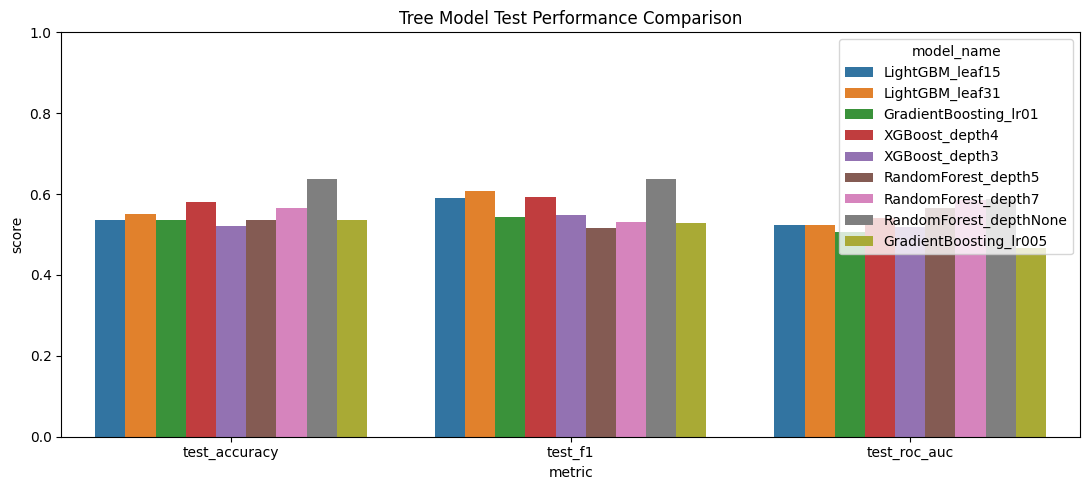

In [18]:
results_melted = results_df.melt(
    id_vars="model_name",
    value_vars=["test_accuracy", "test_f1", "test_roc_auc"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(11, 5))
sns.barplot(data=results_melted, x="metric", y="score", hue="model_name")
plt.title("Tree Model Test Performance Comparison")
plt.ylim(0.0, 1.0)
plt.tight_layout()
plt.show()

## 9. Inspect the best tree model

In [19]:
best_row = results_df.iloc[0]
best_tree_model_name = best_row["model_name"]
best_tree_model = best_row["model_obj"]
best_tree_probs = best_row["test_probs"]
best_tree_preds = best_row["test_preds"]

print("Best tree model:", best_tree_model_name)
print("Validation accuracy:", best_row["val_accuracy"])
print("Validation F1      :", best_row["val_f1"])
print("Validation ROC-AUC :", best_row["val_roc_auc"])
print("Test accuracy      :", best_row["test_accuracy"])
print("Test F1            :", best_row["test_f1"])
print("Test ROC-AUC       :", best_row["test_roc_auc"])

Best tree model: LightGBM_leaf15
Validation accuracy: 0.6086956521739131
Validation F1      : 0.5970149253731343
Validation ROC-AUC : 0.6666666666666666
Test accuracy      : 0.5362318840579711
Test F1            : 0.5897435897435898
Test ROC-AUC       : 0.5246179966044143


## 10. Confusion matrix and ROC curve of the best tree model

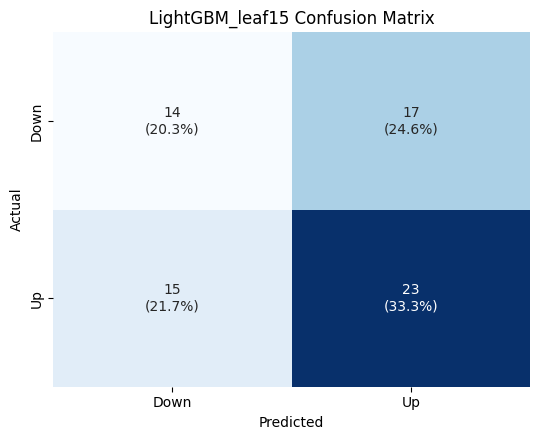

In [20]:
y_test = test_df[TARGET_COL].copy()

plot_confusion_matrix_full(
    y_test,
    best_tree_preds,
    title=f"{best_tree_model_name} Confusion Matrix"
)

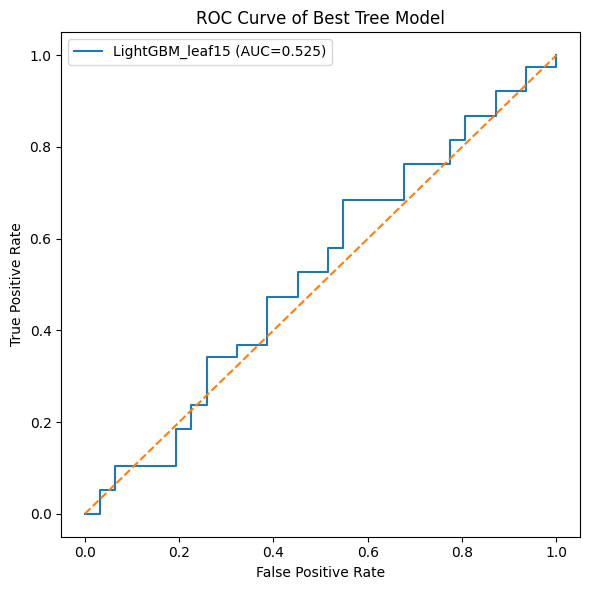

In [21]:
fpr, tpr, _ = roc_curve(y_test, best_tree_probs)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"{best_tree_model_name} (AUC={best_row['test_roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve of Best Tree Model")
plt.legend()
plt.tight_layout()
plt.show()

## 11. Feature importance of the best tree model

,feature,importance
7,roll20_vol,132
1,sentiment_std_lag1,126
0,log_return,114
9,avg_sentiment_roll5_std,113
2,avg_sentiment_lag2,112
6,sentiment_std_roll5_mean,110
14,sentiment_std_lag3,110
3,roll5_ret,109
10,avg_sentiment_lag3,103
8,roll10_ret,97


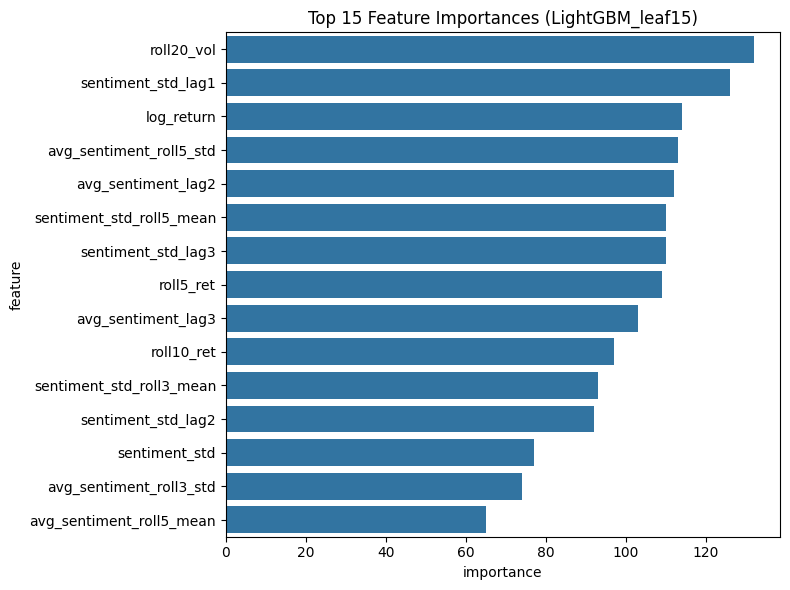

In [22]:
if hasattr(best_tree_model, "feature_importances_"):
    importances = pd.DataFrame({
        "feature": feature_cols,
        "importance": best_tree_model.feature_importances_
    }).sort_values("importance", ascending=False)

    display(importances.head(20))

    plt.figure(figsize=(8, 6))
    sns.barplot(data=importances.head(15), y="feature", x="importance")
    plt.title(f"Top 15 Feature Importances ({best_tree_model_name})")
    plt.tight_layout()
    plt.show()
else:
    print("This model does not expose feature_importances_.")

## 12. Save results

In [34]:
serializable_results = results_df.drop(columns=["model_obj", "test_preds", "test_probs", "feature_cols"]).to_dict(orient="records")

with open(RESULTS_JSON_PATH, "w") as f:
    json.dump(serializable_results, f, indent=2)

print("Saved tree-model results to:", RESULTS_JSON_PATH)

Saved tree-model results to: c:\Users\diant\OneDrive\Documents\Term 8\CDS\DS_Project_g8\finetuning\data\tree_model_tuning_results_brent.json


## Conclusion...

The LightGBM model achieved the best validation performance with a ROC-AUC of 0.667, indicating that the engineered features, particularly sentiment-based lag features, contain useful predictive information. However, the model’s performance on the test set dropped to a ROC-AUC of 0.525, which is only marginally better than random guessing.

This suggests that while the model is able to learn patterns within the training period, these patterns do not generalize well to unseen data. The drop in performance can be attributed to the **small dataset size** and the highly volatile nature of oil price movements, which are influenced by external macroeconomic and geopolitical factors.

Overall, the results indicate that sentiment features provide weak but detectable signals for price direction prediction, though they are insufficient on their own for robust forecasting.